In [253]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [254]:
import warnings
warnings.filterwarnings('ignore')

# LOAD DATA

In [255]:
import pandas as pd

df = pd.read_csv("/content/Bangladesh_Crime_Dataset_A.csv")
df.head()

,Unnamed: 0,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,...,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime
0,0,7.0,29,wednesday,0,morning,dhaka,dhaka,6.1,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
1,1,1.0,2,wednesday,0,night,dhaka,dhaka,0.0,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
2,2,1.0,4,tuesday,0,night,dhaka,dhaka,0.0,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
3,3,3.0,9,friday,1,night,dhaka,dhaka,0.0,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
4,4,8.0,34,thursday,0,night,dhaka,dhaka,21.9,9,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder


In [256]:
df.shape[0] # jumlah baris

6574

In [257]:
df.shape[1] # jumlah kolom

26

In [258]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              6574 non-null   int64  
 1   incident_month          5917 non-null   float64
 2   incident_week           6574 non-null   int64  
 3   incident_weekday        6574 non-null   object 
 4   weekend                 6574 non-null   int64  
 5   part_of_the_day         6457 non-null   object 
 6   incident_district       6246 non-null   object 
 7   incident_division       6574 non-null   object 
 8   precip                  6574 non-null   float64
 9   visibility              6574 non-null   int64  
 10  heatindex               6574 non-null   int64  
 11  season                  6574 non-null   object 
 12  male_population         6574 non-null   int64  
 13  female_population       6574 non-null   int64  
 14  total_population        6574 non-null   

In [259]:
df = df.drop(columns=['Unnamed: 0'])

In [260]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_month          5917 non-null   float64
 1   incident_week           6574 non-null   int64  
 2   incident_weekday        6574 non-null   object 
 3   weekend                 6574 non-null   int64  
 4   part_of_the_day         6457 non-null   object 
 5   incident_district       6246 non-null   object 
 6   incident_division       6574 non-null   object 
 7   precip                  6574 non-null   float64
 8   visibility              6574 non-null   int64  
 9   heatindex               6574 non-null   int64  
 10  season                  6574 non-null   object 
 11  male_population         6574 non-null   int64  
 12  female_population       6574 non-null   int64  
 13  total_population        6574 non-null   int64  
 14  gender_ration           6574 non-null   

# EDA

## missing value

In [261]:
df.isna().sum()

,0
incident_month,657
incident_week,0
incident_weekday,0
weekend,0
part_of_the_day,117
incident_district,328
incident_division,0
precip,0
visibility,0
heatindex,0


In [262]:
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
print(pd.concat([missing_data, missing_percentage], axis=1, keys=['Total Missing Value', 'Percent']))

                        Total Missing Value   Percent
incident_month                          657  9.993915
incident_week                             0  0.000000
incident_weekday                          0  0.000000
weekend                                   0  0.000000
part_of_the_day                         117  1.779738
incident_district                       328  4.989352
incident_division                         0  0.000000
precip                                    0  0.000000
visibility                                0  0.000000
heatindex                                 0  0.000000
season                                    0  0.000000
male_population                           0  0.000000
female_population                         0  0.000000
total_population                          0  0.000000
gender_ration                             0  0.000000
average_household_size                    0  0.000000
density_per_kmsq                          0  0.000000
literacy_rate               

In [263]:
df['incident_month'] = df['incident_month'].astype('Int64')

### numerical checks

In [264]:
numerical_cols = df.select_dtypes(include=np.number).columns
df[numerical_cols].skew()

,0
incident_month,0.060548
incident_week,0.065521
weekend,1.014758
precip,4.343636
visibility,-2.140683
heatindex,-0.383732
male_population,2.041895
female_population,2.018735
total_population,2.031859
gender_ration,1.717372


In [265]:
df['incident_month'].skew()

np.float64(0.06054777971948023)

In [266]:
# Although incident_month is stored as an integer to preserve its temporal order,
# it is conceptually a categorical time indicator.
# Therefore, mode imputation is applied instead of mean or median to avoid creating non-interpretable values.

df['incident_month'].describe()

,incident_month
count,5917.0
mean,6.210749
std,3.319075
min,1.0
25%,3.0
50%,6.0
75%,9.0
max,12.0


In [267]:
df['incident_month'].fillna(df['incident_month'].mode()[0], inplace=True)

In [268]:
df['literacy_rate'].skew()

np.float64(0.05185138757319974)

In [269]:
df['literacy_rate'].describe()

,literacy_rate
count,6246.000000
mean,55.742683
std,12.082504
min,26.700000
25%,46.600000
50%,53.900000
75%,67.200000
max,74.600000


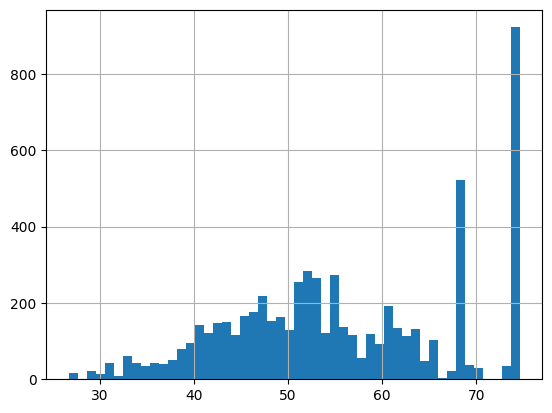

In [270]:
import matplotlib.pyplot as plt

df['literacy_rate'].hist(bins=50)
plt.show() # tidak right skewed dan tidak left skewed maka diimpute menggunakan mean

In [271]:
literacy_mean = df['literacy_rate'].mean()
df['literacy_rate'] = df['literacy_rate'].fillna(literacy_mean)

In [272]:
df.isna().sum()

,0
incident_month,0
incident_week,0
incident_weekday,0
weekend,0
part_of_the_day,117
incident_district,328
incident_division,0
precip,0
visibility,0
heatindex,0


### categorical checks

In [273]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['incident_weekday', 'part_of_the_day', 'incident_district',
       'incident_division', 'season', 'crime'],
      dtype='object')

In [274]:
for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))


=== incident_weekday ===
incident_weekday
tuesday      1010
monday        984
wednesday     976
thursday      937
saturday      917
friday        883
sunday        867
Name: count, dtype: int64

=== part_of_the_day ===
part_of_the_day
night        3179
morning      1946
noon          517
evening       484
afternoon     331
NaN           117
Name: count, dtype: int64

=== incident_district ===
incident_district
dhaka              1115
chattogram          464
NaN                 328
mymensingh          250
jashore             242
dinajpur            195
narayanganj         167
bogura              164
gazipur             162
pabna               161
tangail             151
sylhet              147
rajshahi            134
brahmanbaria        124
habiganj            117
rangpur             109
patuakhali          108
jamalpur            102
moulvibazar         101
faridpur             97
pirojpur             93
lalmonirhat          93
thakurgaon           86
joypurhat            82
barisal  

In [275]:
# missin value in 'part_of_the_day' column
pod_mode = df['part_of_the_day'].mode()[0]
df['part_of_the_day'] = df['part_of_the_day'].fillna(pod_mode)

In [276]:
pd.set_option('display.max_rows', None)
df['incident_district'].value_counts(dropna=False)

,count
incident_district,
dhaka,1115
chattogram,464
NaN,328
mymensingh,250
jashore,242
dinajpur,195
narayanganj,167
bogura,164
gazipur,162


In [277]:
df['incident_district'].isna().sum()

np.int64(328)

In [278]:
# impute incident_district dengan modus
district_mode = df['incident_district'].mode()[0]
df['incident_district'] = df['incident_district'].fillna(district_mode)

In [279]:
df.isna().sum()

,0
incident_month,0
incident_week,0
incident_weekday,0
weekend,0
part_of_the_day,0
incident_district,0
incident_division,0
precip,0
visibility,0
heatindex,0


In [280]:
# anomaly incident_division -> isi records yang inkosisten
df['incident_division'] = (
    df['incident_division']
    .str.lower()
    .str.strip()
)

In [281]:
df['incident_division'].value_counts()

,count
incident_division,
dhaka,2046
chattogram,1061
rajshahi,782
rangpur,703
khulna,697
mymensingh,449
sylhet,424
barisal,408
gazipur,4


In [282]:
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['incident_month', 'incident_week', 'weekend', 'precip', 'visibility',
       'heatindex', 'male_population', 'female_population', 'total_population',
       'gender_ration', 'average_household_size', 'density_per_kmsq',
       'literacy_rate', 'religious_institution', 'playground', 'park',
       'police_station', 'school', 'college'],
      dtype='object')

## Outliers

In [283]:
df[num_cols].describe()

,incident_month,incident_week,weekend,precip,visibility,heatindex,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college
count,6574.0,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6.574000e+03,6.574000e+03,6.574000e+03,6574.000000,6574.000000,6.574000e+03,6574.000000,6574.00000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000
mean,6.389565,25.193946,0.273806,6.187998,9.488287,31.597657,8.936342e+05,7.544586e+05,1.648104e+06,104.429723,4.965023,1.891212e+52,55.742683,1232.03164,42.504411,3.863706,11.762093,75.218893,15.479617
std,3.194237,14.517965,0.445944,11.989998,0.922742,5.502593,1.605205e+06,1.284180e+06,2.889245e+06,10.387173,1.422850,1.354499e+54,11.777181,1245.17044,44.857967,5.883186,19.604510,71.743767,19.721917
min,1.0,1.000000,0.000000,0.000000,4.000000,15.000000,1.132000e+04,1.124700e+04,2.287100e+04,84.000000,3.580000,5.615431e-61,26.700000,0.00000,0.000000,0.000000,-1.000000,1.000000,0.000000
25%,4.0,13.000000,0.000000,0.000000,9.000000,27.000000,1.319300e+05,1.339960e+05,2.652760e+05,98.000000,4.110000,9.100000e+02,47.300000,519.00000,5.000000,0.000000,2.000000,30.000000,4.000000
50%,7.0,25.000000,0.000000,0.800000,10.000000,33.000000,1.872290e+05,1.870170e+05,3.765500e+05,101.000000,4.440000,1.239000e+03,54.800000,818.00000,25.000000,1.000000,3.000000,45.000000,8.000000
75%,9.0,37.000000,1.000000,7.500000,10.000000,36.000000,3.917070e+05,3.811572e+05,7.757330e+05,109.000000,5.100000,4.318000e+03,65.400000,1125.00000,78.000000,3.000000,6.000000,86.000000,15.000000
max,12.0,53.000000,1.000000,204.600000,10.000000,43.000000,4.931802e+06,3.974237e+06,8.906039e+06,203.000000,8.420000,1.090315e+56,74.600000,4289.00000,253.000000,17.000000,74.000000,242.000000,64.000000


In [284]:
# drop gender_ratio column because its irrelevant, contained extreme and non-interpretable values,
# indicating data corruption, and was therefore removed from the analysis.
df = df.drop(columns=['gender_ration'])

In [285]:
# police station anomaly
(df['police_station'] < 0).sum()

np.int64(1)

In [286]:
df.loc[df['police_station'] < 0, 'police_station'] = np.nan

In [287]:
df['police_station'].skew()

np.float64(1.9189530406382271)

In [288]:
df['police_station'] = df['police_station'].fillna(df['police_station'].median())


In [289]:
outlier_summary = {}

# Update num_cols to reflect the current numerical columns in df
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_summary_df = (
    pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['outlier_count'])
    .sort_values('outlier_count', ascending=False)
)

outlier_summary_df

,outlier_count
density_per_kmsq,1307
park,1288
male_population,1250
total_population,1250
female_population,1250
police_station,1225
college,895
religious_institution,891
average_household_size,872
school,872


## duplicated checks

In [290]:
df.duplicated().sum()

np.int64(341)

In [291]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

A total of 270 duplicate records were identified, accounting for approximately 4% of the dataset. These duplicates were removed to prevent double-counting of crime incidents.

In [292]:
df.describe()

,incident_month,incident_week,weekend,precip,visibility,heatindex,male_population,female_population,total_population,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college
count,6233.0,6233.000000,6233.000000,6233.000000,6233.000000,6233.000000,6.233000e+03,6.233000e+03,6.233000e+03,6233.000000,6.233000e+03,6233.000000,6233.000000,6233.000000,6233.000000,6233.000000,6233.000000,6233.000000
mean,6.42291,25.293438,0.273223,6.202936,9.486924,31.597144,8.933476e+05,7.543889e+05,1.647749e+06,4.961588,1.994678e+52,55.807486,1231.469918,42.789187,3.874057,11.754693,75.440558,15.479865
std,3.184708,14.513640,0.445650,12.060938,0.924213,5.485063,1.602680e+06,1.282166e+06,2.884705e+06,1.421535,1.391055e+54,11.722880,1243.052258,45.081575,5.885516,19.582213,71.576490,19.683168
min,1.0,1.000000,0.000000,0.000000,4.000000,15.000000,1.132000e+04,1.124700e+04,2.287100e+04,3.580000,5.615431e-61,26.700000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,4.0,13.000000,0.000000,0.000000,9.000000,27.000000,1.319300e+05,1.339960e+05,2.652760e+05,4.110000,9.180000e+02,47.400000,519.000000,5.000000,0.000000,2.000000,30.000000,4.000000
50%,7.0,25.000000,0.000000,0.800000,10.000000,33.000000,1.882750e+05,1.884070e+05,3.803010e+05,4.440000,1.239000e+03,54.900000,818.000000,25.000000,1.000000,3.000000,45.000000,8.000000
75%,9.0,37.000000,1.000000,7.500000,10.000000,36.000000,3.917070e+05,3.840260e+05,7.757330e+05,5.040000,4.318000e+03,65.400000,1125.000000,78.000000,3.000000,6.000000,86.000000,15.000000
max,12.0,53.000000,1.000000,204.600000,10.000000,43.000000,4.931802e+06,3.974237e+06,8.906039e+06,8.420000,1.090315e+56,74.600000,4289.000000,253.000000,17.000000,74.000000,242.000000,64.000000


# UJI KORELASI

## pearson

In [293]:
crime_map = {
    'murder': 0,
    'rape': 1,
    'assault': 2,
    'bodyfound': 3,
    'kidnap': 4,
    'robbery': 5
}

df['crime_tmp'] = df['crime'].map(crime_map)


In [294]:
num_cols = [
    'precip', 'visibility', 'heatindex',
    'total_population', 'average_household_size',
    'density_per_kmsq', 'literacy_rate',
    'religious_institution', 'playground',
    'park', 'police_station', 'school', 'college'
]

pearson_corr = (
    df[num_cols + ['crime_tmp']]
    .corr(method='pearson')['crime_tmp']
    .sort_values(ascending=False)
)

pearson_corr


,crime_tmp
crime_tmp,1.000000
total_population,0.127926
park,0.125933
college,0.124943
police_station,0.120565
religious_institution,0.115570
average_household_size,0.113586
school,0.112254
literacy_rate,0.107671
playground,0.064784


After normalizing categorical variables, Chi-square tests show that time of day, district, division, and season are significantly associated with crime categories (p < 0.05), while the day of the week does not exhibit a significant relationship.

In [295]:
pearson_drop_cols = [
    'visibility',
    'density_per_kmsq',
    'precip',
    'heatindex'
]

df.drop(columns=pearson_drop_cols, inplace=True)


## chi square

In [296]:
cat_cols = [
    'part_of_the_day',
    'incident_district',
    'incident_division',
    'season',
    'incident_weekday'
]


In [297]:
from scipy.stats import chi2_contingency

chi_results = []

for col in cat_cols:
    contingency_table = pd.crosstab(df[col], df['crime'])
    chi2, p, _, _ = chi2_contingency(contingency_table)
    chi_results.append([col, p])

chi_df = (
    pd.DataFrame(chi_results, columns=['Feature', 'p_value'])
    .sort_values('p_value')
)

chi_df


,Feature,p_value
0,part_of_the_day,2.352733e-220
1,incident_district,9.330638e-61
2,incident_division,9.254428e-38
3,season,1.957682e-13
4,incident_weekday,4.934344e-01


In [298]:
df.drop(columns=['incident_weekday'], inplace=True)

In [299]:
df.drop(columns=['crime_tmp'], inplace=True)

Chi-square tests were conducted to assess the association between categorical variables and crime categories. The results indicate that time of day, district, division, and season are significantly associated with crime types (p < 0.05). In contrast, incident weekday does not show a statistically significant association (p = 0.49) and was therefore excluded from further analysis.

# ENCODE

In [300]:
cat_cols = [
    'part_of_the_day',
    'incident_district',
    'incident_division',
    'season'
]

In [301]:
X_num = df.drop(columns=cat_cols + ['crime'])
X_cat = df[cat_cols]

In [302]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    drop='first',
    sparse_output=False, # Changed 'sparse' to 'sparse_output'
    handle_unknown='ignore'
)

X_cat_encoded = ohe.fit_transform(X_cat)

X_cat_encoded_df = pd.DataFrame(
    X_cat_encoded,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df.index
)

In [303]:
df_encoded = pd.concat(
    [X_num, X_cat_encoded_df],
    axis=1
)

In [304]:
df_encoded.info()


<class 'pandas.core.frame.DataFrame'>
Index: 6233 entries, 0 to 6573
Data columns (total 91 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   incident_month                     6233 non-null   Int64  
 1   incident_week                      6233 non-null   int64  
 2   weekend                            6233 non-null   int64  
 3   male_population                    6233 non-null   int64  
 4   female_population                  6233 non-null   int64  
 5   total_population                   6233 non-null   int64  
 6   average_household_size             6233 non-null   float64
 7   literacy_rate                      6233 non-null   float64
 8   religious_institution              6233 non-null   int64  
 9   playground                         6233 non-null   int64  
 10  park                               6233 non-null   int64  
 11  police_station                     6233 non-null   float64
 1

# Scalling

In [305]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

# MODELLING

## Elbow Method

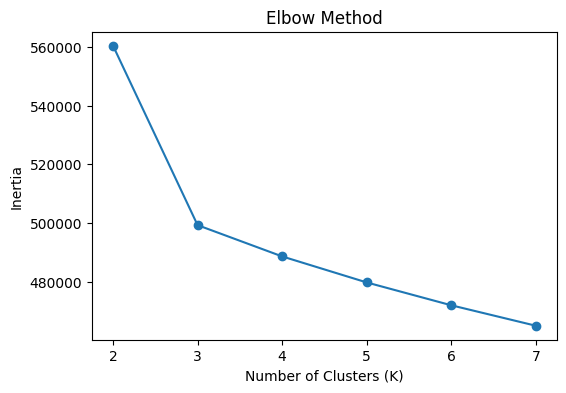

In [306]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 8)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia') # TOTAL JARAK DALAM CLUSTER
plt.title('Elbow Method')
plt.show()

## Silhoutte Analysis

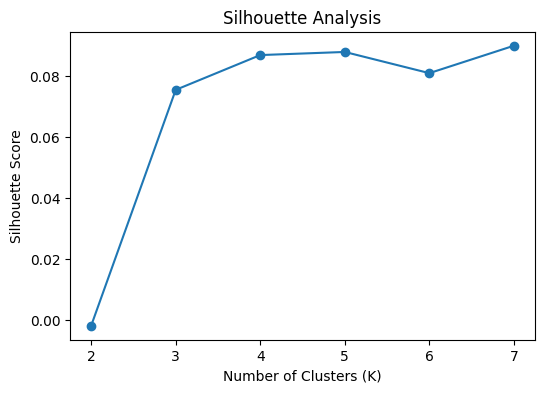

In [307]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

In [308]:
kmeans_final = KMeans(n_clusters=3, random_state=42)
df_encoded['cluster'] = kmeans_final.fit_predict(X_scaled)

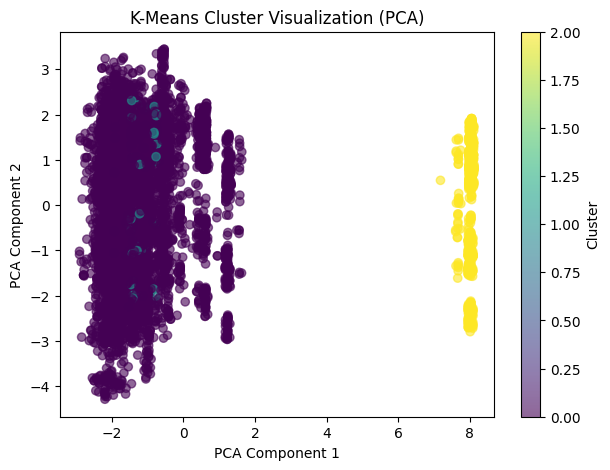

In [309]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_encoded['cluster'],
    cmap='viridis',
    alpha=0.6
)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Cluster Visualization (PCA)')
plt.colorbar(label='Cluster')
plt.show()

K-Means clustering was tuned using two evaluation metrics: the Elbow Method and Silhouette Score. The Elbow Method suggested diminishing returns beyond five clusters, while the Silhouette Score increased gradually with larger K values. Considering the trade-off between cluster separation and interpretability for policy-oriented analysis, three clusters were selected as the final solution. The resulting clusters were visualized using PCA, revealing reasonable separation with some overlap, which is expected in high-dimensional socio-demographic data.

# EACH CLUSTER PROFILE

In [310]:
df_profile = df.copy()
df_profile['cluster'] = df_encoded['cluster']

In [311]:
# profil numerik tiap cluster (mean)

numeric_cols = [
    'total_population', 'average_household_size',
    'literacy_rate',
    'religious_institution', 'playground',
    'park', 'police_station', 'school', 'college'
]

cluster_numeric_profile = (
    df_profile
    .groupby('cluster')[numeric_cols]
    .mean()
)

cluster_numeric_profile

,total_population,average_household_size,literacy_rate,religious_institution,playground,park,police_station,school,college
cluster,,,,,,,,,
0,5.471175e+05,4.436114,53.065475,764.007155,33.460742,1.893240,4.457164,50.174732,8.053474
1,2.663218e+05,4.360204,53.709184,856.877551,75.704082,0.857143,2.163265,44.234694,9.979592
2,8.906039e+06,8.420000,73.730366,4289.000000,99.000000,17.000000,59.930825,242.000000,64.000000


Hasil profiling cluster menunjukkan perbedaan karakteristik wilayah yang jelas. Cluster 1 merepresentasikan wilayah dengan populasi relatif kecil dan keterbatasan fasilitas publik, yang mencerminkan daerah rural atau sub-urban. Cluster 0 menunjukkan karakteristik wilayah semi-urban dengan tingkat populasi dan infrastruktur menengah. Sementara itu, Cluster 2 menggambarkan wilayah metropolitan dengan populasi yang sangat besar, tingkat literasi yang tinggi, serta ketersediaan fasilitas publik dan keamanan yang jauh lebih tinggi dibandingkan cluster lainnya.

In [312]:
# distirbusi crime tiap cluster

crime_distribution = (
    df_profile
    .groupby('cluster')['crime']
    .value_counts(normalize=True)
    .rename('proportion')
)

crime_distribution

cluster  crime    
0        murder       0.244210
         bodyfound    0.230088
         rape         0.183770
         assault      0.165317
         kidnap       0.100923
         robbery      0.075692
1        rape         0.265306
         assault      0.255102
         murder       0.163265
         bodyfound    0.153061
         kidnap       0.102041
         robbery      0.061224
2        bodyfound    0.277913
         robbery      0.184466
         assault      0.178398
         murder       0.143204
         rape         0.138350
         kidnap       0.077670
Name: proportion, dtype: float64

In [313]:
crime_distribution.unstack().fillna(0)

crime,assault,bodyfound,kidnap,murder,rape,robbery
cluster,,,,,,
0,0.165317,0.230088,0.100923,0.244210,0.183770,0.075692
1,0.255102,0.153061,0.102041,0.163265,0.265306,0.061224
2,0.178398,0.277913,0.077670,0.143204,0.138350,0.184466


The distribution of crime types varies across clusters. Cluster 0 is dominated by serious violent crimes, particularly murder, indicating higher severity incidents in semi-urban regions. Cluster 1 exhibits a more balanced mix of assault, murder, and rape, suggesting transitional areas with interpersonal violence. Cluster 2 shows a more diverse crime composition, including higher proportions of robbery and body-found cases, which is consistent with urban environments characterized by greater population density and mobility.